# <font color=blue>__Workshop 1: Whole Genome/Exome Sequencing__</font>
###  Machine Learning and Bioinformatics (MLBI) Lab @ DKU, 2025 <br>
### __Practices__
>#### 1. Reference Genome & Annotation (GTF) Preparation
>#### 2. WES Read alignment (BWA)
>#### 3. Variant calling (GATK Mutect2)
>#### 4. Copy Number Variation analysis (CNVkit)

<br>

In [ ]:
# Colab 새 런타임에서 mlbi-bitool이 설치되어 있지 않으면 아래 줄의 주석을 풀고 실행하세요.
# !pip install -U mlbi-bitool

In [ ]:
from mlbi_bitool import install_common_bi_tools

install_common_bi_tools("wes")      # WES 노트북

<!-- MLBI-EDU-NOTE: overview -->
### 실습 목표와 흐름
이 노트북은 작은 WES 예제 데이터를 사용해 변이 분석 파이프라인의 전체 구조를 익히는 데 초점을 둡니다. 실제 연구 데이터에서는 전처리와 QC가 더 길어지지만, 여기서는 핵심 파일 형식과 명령 흐름을 빠르게 확인합니다.

- 입력 데이터: 선택된 염색체의 reference genome/annotation, paired-end WES FASTQ, GATK 보조 VCF
- 주요 도구: BWA, samtools, GATK Mutect2, Funcotator, CNVkit
- 산출물: 정렬된 BAM, somatic VCF/MAF, CNV segment summary
- 읽는 방법: 각 단계에서 “입력 파일이 무엇인지”, “새로 만들어지는 파일이 무엇인지”, “다음 단계에서 왜 필요한지”를 확인합니다.


In [1]:
import time, os, copy
import numpy as np
import pandas as pd

## To download datasets for practice
from mlbi_bitool.load_datasets import load_bi_workshop_data, load_workshop_data

import mlbi_bitool.align as aln
import mlbi_bitool.util as utl
from mlbi_bitool import gatk
from mlbi_bitool import cnv


https://github.com/combio-dku


## <font color=blue>__Practice 1: Reference Genome and annotation (GTF)__</font>

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 분석의 기준 좌표계를 준비합니다. FASTA는 염기서열 자체이고, GTF는 gene/transcript/exon의 위치와 방향을 담은 annotation입니다. 뒤의 alignment, variant calling, CNV 분석은 모두 이 좌표계 위에서 수행됩니다.


### __Download practice data__

<!-- MLBI-EDU-NOTE: data -->
아래 셀은 실습에 필요한 작은 예제 데이터를 내려받습니다. 이미 같은 이름의 폴더가 있으면 다시 받지 않도록 되어 있으므로, 수업 중에는 셀을 여러 번 실행해도 보통 안전합니다.


In [3]:
load_bi_workshop_data()

The item must be one of .. 
   BI_Files_for_GATK
   BI_Files_for_GATK_full
   BI_RNAseq_CRC_chr12
   BI_RNAseq_CRC_chr12_bam
   BI_RNAseq_pacbio_chr12
   BI_RNAseq_pacbio_chr12_bam
   BI_RNAseq_sample_chr12
   BI_RefGenome_hg38_sel
   BI_WES_PDAC_chr17
   BI_WES_PDAC_chr17_bam
   BI_WES_sample_chr17
   ML_CCLE_CTRPv2
   ML_CancerSEEK
   ML_GDSC
   ML_Genome_to_Fields
   ML_METABRIC
   ML_QM9
   ML_TCGA_BRCA 


In [5]:
if not os.path.isdir('RefGenome_hg38_sel'):
    load_bi_workshop_data('BI_RefGenome_hg38_sel')

Downloading...
From (original): https://drive.google.com/uc?id=1uIHwlS3N4TsN7sJdD3j5Hf8B_clTQXHl
From (redirected): https://drive.google.com/uc?id=1uIHwlS3N4TsN7sJdD3j5Hf8B_clTQXHl&confirm=t&uuid=18be2029-d330-4a71-bfc7-b94ce28a8de6
To: /mnt/HDD2/Google_drive/BI_training_dev/downloaded
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119M/119M [00:08<00:00, 13.2MB/s]


Folder extracted to: RefGenome_hg38_sel


In [6]:
if not os.path.isdir('WES_PDAC_chr17'):
    load_bi_workshop_data('BI_WES_PDAC_chr17')

Downloading...
From (original): https://drive.google.com/uc?id=1l88p48edaw7oHTSdCFQgXALoUAdYr2nT
From (redirected): https://drive.google.com/uc?id=1l88p48edaw7oHTSdCFQgXALoUAdYr2nT&confirm=t&uuid=e7ab789a-bd1e-41b4-a258-fefe94f04afa
To: /mnt/HDD2/Google_drive/BI_training_dev/downloaded
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.52G/2.52G [03:00<00:00, 14.0MB/s]


Folder extracted to: WES_PDAC_chr12


In [47]:
if not os.path.isdir('Files_for_GATK_chr12'):
    load_bi_workshop_data('BI_Files_for_GATK')

Downloading...
From (original): https://drive.google.com/uc?id=1pbMIMvoqBqGE9yMKUg2E-f2m4P8mmN4Y
From (redirected): https://drive.google.com/uc?id=1pbMIMvoqBqGE9yMKUg2E-f2m4P8mmN4Y&confirm=t&uuid=900953c7-a7fc-4edd-a410-6e3f491150c9
To: /mnt/HDD2/Google_drive/BI_training_dev/downloaded
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 383M/383M [00:24<00:00, 15.7MB/s]


Folder extracted to: Files_for_GATK_chr12


### __1. Genome file (FASTA format)__

In [7]:
os.getcwd()

'/mnt/HDD2/Google_drive/BI_training_dev'

In [8]:
ref_src = 'RefGenome_hg38_sel'
os.listdir(ref_src)

['Homo_sapiens_assembly38_chr7_12_17.gtf',
 'Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai']

In [9]:
genome_file = ref_src + '/Homo_sapiens_assembly38_chr7_12_17.fa'
genome = utl.load_genome(genome_file, verbose =True)

Num.Chr =  3  loaded                             


In [10]:
genome.keys()

dict_keys(['chr7', 'chr12', 'chr17'])

In [11]:
genome['chr17'].len

83257441

In [12]:
genome['chr17'].seq[150000:151000]

'TCCCTCCACAGCCACTAAGGCCTTAGGCTCTGATGCAGAACAGCTGTCTTCCTCTGAGGCTCAGAGAGGGGGAGTGACTTGCCCAAGGTCACACAGCCTGCAAGCACAAGCGTGGTGCTTGAAAGCCAGGCTCAGACTCCTTTCTCTATGACAGGGAGGTCATGTGCAGGCTGGAGAAGGGGACAAGAGGTCCCCAACTTCTTTGCAAAGCTTCTCACCCTGTTCCTGCATAGATAATTGCATGACAATTGCCTTGTCCCTGCTGAATGTGCTCTGGGGTCTCTGGGGTCTCACCCACGACCAACTCCCTGGGCCTGGCACCAGGGAGCTTAACAAACATCTGTCCAGCGAATACCTGCATCCCTAGAAGTGAAGCCACCGCCCAAAGACACGCCCATGTCCAGCTTAACCTGCATCCCTAGAAGTGAAGGCACCGCCCAAAGACACGCCCATGTCCAGCTTATTCTGCCCAGTTCCTCTCCAGAAAGGCTGCATGGTTGACACACAGTGCCTGCGACAAAGCTGAATGCTATCATTTAAAAACTCCTTGCTGGTTTGAGAGGCAGAAAATGATATCTCATAGTTGCTTTACTTTGCATATTTTAAAATTGTGACTTTCATGGCATAAATAATACTGGTTTATTACAGAAGCACTAGAAAATGCATGTGGACAAAAGTTGGGATTAGGAGAGAGAAATGAAGACATATGTCCACACAAAAACCTGTTCATTGCAGCTTTCTACCATCACCAAAAATTGCAAACAACCACACGCCCTTCAACTGGGGAACTCATCAACAACAAACTTGTGGTTTACCCACACAATGGAAGACCACTTAGCAACAAAAAGGACCAAACTCCTGGTACATGCAACTGACAGATGAATCTCAAACGCATTCCTCCGTGTGAAAGAAGCCGGACTCACAGGGCAACACACTATCTGACTGTTTCATGGGAAAGTCTGGAAACGGCAACACCATTGAGACAGAAAACAGGTGAGT

### __2. GTF annotation__

In [13]:
d = 'RefGenome_hg38_sel'
os.listdir(d)

['Homo_sapiens_assembly38_chr7_12_17.gtf',
 'Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai']

In [14]:
## Use linux command 'head' to check GTF file contents line-by-line
!head -n 20 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf'

#  !genome-build GRCh38.p12
#  !genome-version GRCh38
#  !genome-date 2013-12
#  !genome-build-accession NCBI:GCA_000001405.27
#  !genebuild-last-updated 2018-11
chr7	havana	gene	12704	27234	.	+	.	gene_id "ENSG00000283061"; gene_version "1"; gene_name "AC215522.3"; gene_source "havana"; gene_biotype "lincRNA";
chr7	havana	transcript	12704	27199	.	+	.	gene_id "ENSG00000283061"; gene_version "1"; transcript_id "ENST00000635602"; transcript_version "1"; gene_name "AC215522.3"; gene_source "havana"; gene_biotype "lincRNA"; transcript_name "AC215522.3-201"; transcript_source "havana"; transcript_biotype "lincRNA"; tag "basic"; transcript_support_level "5";
chr7	havana	exon	12704	12822	.	+	.	gene_id "ENSG00000283061"; gene_version "1"; transcript_id "ENST00000635602"; transcript_version "1"; exon_number "1"; gene_name "AC215522.3"; gene_source "havana"; gene_biotype "lincRNA"; transcript_name "AC215522.3-201"; transcript_source "havana"; transcript_biotype "lincRNA"; exon_id "ENSE00003788848

In [15]:
## Load GTF lines as Data Frame
gtf_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf'

gtf_lines, hdr_lines = utl.load_gtf(gtf_file)
df_gtf = pd.DataFrame( gtf_lines )

Loading GTF ... done 465202 lines. 


In [16]:
with pd.option_context("display.width", None,
                       "display.max_colwidth", None):
    display( df_gtf.iloc[:3] )

,chr,src,feature,start,end,score,strand,frame,attr,gid,gname,tid,tname,eid,biotype,t_biotype,cov,fpkm,tpm
0,chr7,havana,gene,12704,27234,.,+,.,"gene_id ""ENSG00000283061""; gene_version ""1""; gene_name ""AC215522.3""; gene_source ""havana""; gene_biotype ""lincRNA"";",ENSG00000283061,AC215522.3,,,,lincRNA,,,,
1,chr7,havana,transcript,12704,27199,.,+,.,"gene_id ""ENSG00000283061""; gene_version ""1""; transcript_id ""ENST00000635602""; transcript_version ""1""; gene_name ""AC215522.3""; gene_source ""havana""; gene_biotype ""lincRNA""; transcript_name ""AC215522.3-201""; transcript_source ""havana""; transcript_biotype ""lincRNA""; tag ""basic""; transcript_support_level ""5"";",ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,,lincRNA,lincRNA,,,
2,chr7,havana,exon,12704,12822,.,+,.,"gene_id ""ENSG00000283061""; gene_version ""1""; transcript_id ""ENST00000635602""; transcript_version ""1""; exon_number ""1""; gene_name ""AC215522.3""; gene_source ""havana""; gene_biotype ""lincRNA""; transcript_name ""AC215522.3-201""; transcript_source ""havana""; transcript_biotype ""lincRNA""; exon_id ""ENSE00003788848""; exon_version ""1""; tag ""basic""; transcript_support_level ""5"";",ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,ENSE00003788848,lincRNA,lincRNA,,,


In [17]:
df_gtf.drop(columns = ['attr']).head()

,chr,src,feature,start,end,score,strand,frame,gid,gname,tid,tname,eid,biotype,t_biotype,cov,fpkm,tpm
0,chr7,havana,gene,12704,27234,.,+,.,ENSG00000283061,AC215522.3,,,,lincRNA,,,,
1,chr7,havana,transcript,12704,27199,.,+,.,ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,,lincRNA,lincRNA,,,
2,chr7,havana,exon,12704,12822,.,+,.,ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,ENSE00003788848,lincRNA,lincRNA,,,
3,chr7,havana,exon,26965,27199,.,+,.,ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,ENSE00003789861,lincRNA,lincRNA,,,
4,chr7,havana,transcript,24314,27234,.,+,.,ENSG00000283061,AC215522.3,ENST00000635506,AC215522.3-202,,lincRNA,lincRNA,,,


In [18]:
b = df_gtf['feature'] == 'transcript'
df_gtf.drop(columns = ['attr']).loc[b].head()

,chr,src,feature,start,end,score,strand,frame,gid,gname,tid,tname,eid,biotype,t_biotype,cov,fpkm,tpm
1,chr7,havana,transcript,12704,27199,.,+,.,ENSG00000283061,AC215522.3,ENST00000635602,AC215522.3-201,,lincRNA,lincRNA,,,
4,chr7,havana,transcript,24314,27234,.,+,.,ENSG00000283061,AC215522.3,ENST00000635506,AC215522.3-202,,lincRNA,lincRNA,,,
8,chr7,havana,transcript,19018,31194,.,-,.,ENSG00000282572,AC215522.2,ENST00000635373,AC215522.2-201,,processed_transcript,lincRNA,,,
13,chr7,havana,transcript,19619,35457,.,-,.,ENSG00000282572,AC215522.2,ENST00000633163,AC215522.2-202,,processed_transcript,lincRNA,,,
18,chr7,havana,transcript,31390,35489,.,-,.,ENSG00000282572,AC215522.2,ENST00000632586,AC215522.2-203,,processed_transcript,processed_transcript,,,


In [19]:
df_gtf['feature'].value_counts()

feature
exon               214097
CDS                126904
transcript          34802
three_prime_utr     26341
five_prime_utr      25869
start_codon         14940
stop_codon          13320
gene                 8922
Selenocysteine          7
Name: count, dtype: int64

In [20]:
df_gtf['strand'].value_counts()

strand
-    234590
+    230612
Name: count, dtype: int64

#### 특정 유전자의 isoform 및 그 구성 확인해보기 

In [21]:
b = df_gtf['gname'] == 'ERBB2'
df_tmp = df_gtf.loc[b, :].drop(columns = ['attr', 'gid', 'tid', 'eid'])

with pd.option_context("display.max_rows", None):
    display( df_tmp )

,chr,src,feature,start,end,score,strand,frame,gname,tname,biotype,t_biotype,cov,fpkm,tpm
367202,chr17,ensembl_havana,gene,39687914,39730426,.,+,.,ERBB2,,protein_coding,,,,
367203,chr17,havana,transcript,39687914,39728361,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367204,chr17,havana,exon,39687914,39688278,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367205,chr17,havana,exon,39688696,39688800,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367206,chr17,havana,exon,39693261,39693325,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367207,chr17,havana,exon,39694988,39695181,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367208,chr17,havana,exon,39699537,39699587,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367209,chr17,havana,exon,39706990,39707141,.,+,.,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367210,chr17,havana,CDS,39707007,39707141,.,+,0,ERBB2,ERBB2-219,protein_coding,protein_coding,,,
367211,chr17,havana,start_codon,39707007,39707009,.,+,0,ERBB2,ERBB2-219,protein_coding,protein_coding,,,


#### GTF entry중 feature가 gene인 line들만 골라 저장하기

In [22]:
b = df_gtf['feature'] == 'gene'
df_gtf_gene = df_gtf.loc[b, :]
df_gtf_gene

,chr,src,feature,start,end,score,strand,frame,attr,gid,gname,tid,tname,eid,biotype,t_biotype,cov,fpkm,tpm
0,chr7,havana,gene,12704,27234,.,+,.,"gene_id ""ENSG00000283061""; gene_version ""1""; g...",ENSG00000283061,AC215522.3,,,,lincRNA,,,,
7,chr7,havana,gene,19018,35489,.,-,.,"gene_id ""ENSG00000282572""; gene_version ""2""; g...",ENSG00000282572,AC215522.2,,,,processed_transcript,,,,
22,chr7,havana,gene,37032,37477,.,+,.,"gene_id ""ENSG00000273644""; gene_version ""1""; g...",ENSG00000273644,AC215522.1,,,,processed_pseudogene,,,,
25,chr7,havana,gene,70972,95683,.,-,.,"gene_id ""ENSG00000232325""; gene_version ""4""; g...",ENSG00000232325,AC093627.1,,,,lincRNA,,,,
30,chr7,havana,gene,77038,81178,.,+,.,"gene_id ""ENSG00000242611""; gene_version ""2""; g...",ENSG00000242611,AC093627.6,,,,lincRNA,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465154,chr17,havana,gene,83104255,83106910,.,+,.,"gene_id ""ENSG00000261888""; gene_version ""1""; g...",ENSG00000261888,AC144831.1,,,,lincRNA,,,,
465157,chr17,havana,gene,83132647,83136150,.,-,.,"gene_id ""ENSG00000279143""; gene_version ""1""; g...",ENSG00000279143,AC139099.3,,,,TEC,,,,
465160,chr17,havana,gene,83143951,83221442,.,+,.,"gene_id ""ENSG00000262898""; gene_version ""2""; g...",ENSG00000262898,AC139099.2,,,,lincRNA,,,,
465182,chr17,havana,gene,83220527,83227721,.,-,.,"gene_id ""ENSG00000262094""; gene_version ""1""; g...",ENSG00000262094,AC139099.1,,,,lincRNA,,,,


In [23]:
fname = 'hg38_gene_only.gtf'
utl.save_gtf( fname, df_gtf_gene, hdr = hdr_lines )

Saving GTF ... done. 


#### Genes BED 파일 만들기
bed file: https://en.wikipedia.org/wiki/BED_(file_format) 

In [24]:
df_sel = df_gtf_gene[['chr', 'start', 'end', 'gname', 'biotype']]
df_sel

,chr,start,end,gname,biotype
0,chr7,12704,27234,AC215522.3,lincRNA
7,chr7,19018,35489,AC215522.2,processed_transcript
22,chr7,37032,37477,AC215522.1,processed_pseudogene
25,chr7,70972,95683,AC093627.1,lincRNA
30,chr7,77038,81178,AC093627.6,lincRNA
...,...,...,...,...,...
465154,chr17,83104255,83106910,AC144831.1,lincRNA
465157,chr17,83132647,83136150,AC139099.3,TEC
465160,chr17,83143951,83221442,AC139099.2,lincRNA
465182,chr17,83220527,83227721,AC139099.1,lincRNA


#### Exon length statistics

In [25]:
## Exon length Stats.
df_gtf['len'] = df_gtf['end'] - df_gtf['start'] + 1

b = df_gtf['feature'] == 'exon'
df_tmp = df_gtf.loc[b]

df_tmp['len'].min(), int(df_tmp['len'].median()), int(df_tmp['len'].mean()), df_tmp['len'].max()

(1, 128, 242, 205012)

Text(0.5, 0, 'Exon length')

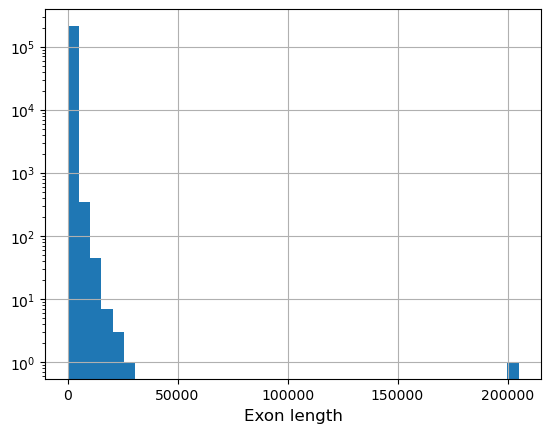

In [26]:
import matplotlib.pyplot as plt

df_tmp['len'].hist( bins = 40, log = True )
plt.xlabel('Exon length', fontsize = 12)

### Homework
1. 위의 GTF line을 parsing하여 각각의 Gene이 몇개의 transcript를 갖는지 확인하고 
   이를 Data Frame으로 정리해 보아라.
   예를 들면, Data Frame의 행수는 Gene의 개수이고 열은 각각 
   Gene ID, Gene Name, Gene이 포함된 Chromosome, Transcript 개수를 포함하도록 구성하라.
2. 1의 Data Frame을 이용하여 Transcript 개수의 histogram을 그려보아라.
3. 위의 GTF line을 parsing하여 각각의 Transcript가 몇개의 exon/CDS를 갖는지 확인하고 
   이를 Data Frame으로 정리해 보아라.
   예를 들면, Data Frame의 행수는 Transcript의 개수이고 열은 각각 
   Transcript ID, Transcript name, Gene ID, Gene Name, 해당 Transcript가 포함된 Chromosome, 
   exon 개수, CDS 개수를 포함하도록 구성하라.
4. 3의 Data Frame을 이용하여 CDS/exon 개수의 histogram을 그려보아라.

#### 과제 제출: 
실행 결과를 확인할 수 있는 jupyer notebook 파일을 Lab_share 폴더의 Homework 폴더 안에 'yyyymmdd-BI-Homework-practice번호-본인이름.ipynb' 파일명으로 저장하라. 

### __3. Checking out FASTQ file format__

In [27]:
d = 'WES_PDAC_chr12'
os.listdir(d)

['PDAC_2_Tumor_chr12_R2.fq.gz',
 'PDAC_4_Normal_chr12_R1.fq.gz',
 'PDAC_4_Tumor_chr12_R1.fq.gz',
 'PDAC_2_Normal_chr12_R1.fq.gz',
 'PDAC_4_Tumor_chr12_R2.fq.gz',
 'PDAC_1_Normal_chr12_R1.fq.gz',
 'PDAC_2_Tumor_chr12_R1.fq.gz',
 'PDAC_1_Tumor_chr12_R1.fq.gz',
 'PDAC_1_Normal_chr12_R2.fq.gz',
 'PDAC_3_Tumor_chr12_R1.fq.gz',
 'PDAC_2_Normal_chr12_R2.fq.gz',
 'PDAC_3_Tumor_chr12_R2.fq.gz',
 'PDAC_4_Normal_chr12_R2.fq.gz',
 'PDAC_3_Normal_chr12_R2.fq.gz',
 'PDAC_1_Tumor_chr12_R2.fq.gz',
 'PDAC_3_Normal_chr12_R1.fq.gz']

In [28]:
## Use linux command 'head' to check GTF file contents line-by-line
!zcat 'WES_PDAC_chr12/PDAC_1_Normal_chr12_R1.fq.gz' | head -n 20 

@A00479:271:HK3CJDSX2:4:1101:1262:9283/1
ACCGAGGTTTTGAACACCGCCATTCTCACTGGAAAGCCTGTTTCAGTTCCTGTCAAAGTCGTGGGGGTCCAGGAGGATGGTTCTGTGGTCGATGTGTCTGAGTCTGTGGAATGCAAGTCTGCCGATGAAGATGTCATTAAGGTAAGGGGGG
+
FFFFFFFFFFF:FFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF
@A00479:271:HK3CJDSX2:4:1101:1398:25708/1
GTAGGCAAGGTAAGTAGTTGGATGAAATCACAGGAAGCATGAATAGTTGTGACCAATTGCAGAAGACTCAAGCTGATTCCATCTCAGGGACACACTCTACCATTCGGGAGATCCCCAACCCATTTGGGTAAAACTGCAAGAGAAAAAAATA
+
FFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFF:FFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,F:F:FFF:FFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFF:FFFF
@A00479:271:HK3CJDSX2:4:1101:1443:37027/1
AATGAAGGAGAAGGTCTGGGGAGGGGTGGGCATCCTGAGGAAGAAGGATCAGACTCAGGATTGCAGGGGAAATGTCTCCTGGGTTGTGAGTGGTAGTTAGCTGGGAGCTTGTCTTTAGGCACAGAGGAAGAGGATCCCTTCAGGGGTTCTG
+
FFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF

In [29]:
## Use linux command 'head' to check GTF file contents line-by-line
!zcat 'WES_PDAC_chr12/PDAC_1_Normal_chr12_R1.fq.gz' | head -n 20 

@A00479:271:HK3CJDSX2:4:1101:1262:9283/1
ACCGAGGTTTTGAACACCGCCATTCTCACTGGAAAGCCTGTTTCAGTTCCTGTCAAAGTCGTGGGGGTCCAGGAGGATGGTTCTGTGGTCGATGTGTCTGAGTCTGTGGAATGCAAGTCTGCCGATGAAGATGTCATTAAGGTAAGGGGGG
+
FFFFFFFFFFF:FFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF
@A00479:271:HK3CJDSX2:4:1101:1398:25708/1
GTAGGCAAGGTAAGTAGTTGGATGAAATCACAGGAAGCATGAATAGTTGTGACCAATTGCAGAAGACTCAAGCTGATTCCATCTCAGGGACACACTCTACCATTCGGGAGATCCCCAACCCATTTGGGTAAAACTGCAAGAGAAAAAAATA
+
FFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFF:FFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,F:F:FFF:FFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFF:FFFF
@A00479:271:HK3CJDSX2:4:1101:1443:37027/1
AATGAAGGAGAAGGTCTGGGGAGGGGTGGGCATCCTGAGGAAGAAGGATCAGACTCAGGATTGCAGGGGAAATGTCTCCTGGGTTGTGAGTGGTAGTTAGCTGGGAGCTTGTCTTTAGGCACAGAGGAAGAGGATCCCTTCAGGGGTTCTG
+
FFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF

## __Practice 2: Read alignment__

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 FASTQ read를 reference genome에 정렬해 BAM 파일을 만듭니다. BAM은 이후 변이 호출과 CNV 분석의 공통 입력이므로, read group, sorting, indexing이 제대로 되었는지 확인하는 습관이 중요합니다.


### __Download and check data__

In [30]:
src_dir = 'RefGenome_hg38_sel/'

flst = os.listdir(src_dir)
flst.sort()
flst

['Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai',
 'Homo_sapiens_assembly38_chr7_12_17.gtf']

In [5]:
src_dir = 'WES_PDAC_chr12/'

flst = os.listdir(src_dir)
flst.sort()
flst

['PDAC_1_Normal_chr12_R1.fq.gz',
 'PDAC_1_Normal_chr12_R2.fq.gz',
 'PDAC_1_Tumor_chr12_R1.fq.gz',
 'PDAC_1_Tumor_chr12_R2.fq.gz',
 'PDAC_2_Normal_chr12_R1.fq.gz',
 'PDAC_2_Normal_chr12_R2.fq.gz',
 'PDAC_2_Tumor_chr12_R1.fq.gz',
 'PDAC_2_Tumor_chr12_R2.fq.gz',
 'PDAC_3_Normal_chr12_R1.fq.gz',
 'PDAC_3_Normal_chr12_R2.fq.gz',
 'PDAC_3_Tumor_chr12_R1.fq.gz',
 'PDAC_3_Tumor_chr12_R2.fq.gz',
 'PDAC_4_Normal_chr12_R1.fq.gz',
 'PDAC_4_Normal_chr12_R2.fq.gz',
 'PDAC_4_Tumor_chr12_R1.fq.gz',
 'PDAC_4_Tumor_chr12_R2.fq.gz']

### __1. Build BWA index of a reference genome__

#### Command: 
bwa index -a ALGORITHM PATH_TO_GENOME 

- PATH_TO_GENOME: full path to the genome file
- ALGORITHM: algorithm to use. 'bwtsw' is a typical one.

If successful, you will see many files in the PATH_TO_GENOME with different extensions.
For detailed options, run "bwa index" 

In [32]:
## Source directory/file description
genome_dir = 'RefGenome_hg38_sel/'
genome_file = genome_dir + 'Homo_sapiens_assembly38_chr7_12_17.fa'
dst_dir = 'index_bwa_hg38_sel'

bwa_idx, cmds = aln.build_index_bwa(genome_file, dst_dir, verbose = True)
bwa_idx

[bwa_index] Pack FASTA... 1.70 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=751757446, availableWord=64896356
[BWTIncConstructFromPacked] 10 iterations done. 99636262 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 191182854 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 272545702 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 344857190 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 409123846 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 466240182 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 517001318 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 562113910 characters processed.
[BWTIncConstructFromPacked] 90 iterations done. 602206070 characters processed.
[BWTIncConstructFromPacked] 100 iterations done. 637836086 characters processed.
[BWTIncConstructFromPacked] 110 iterations done. 669

Path to BWA index: index_bwa_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa


'index_bwa_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'

In [33]:
cmds

'bwa index -a bwtsw -p index_bwa_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'

### __2. WES read alignment using BWA__
- Use BWA-MEM
- Require Read Group Line option for Variant Call
- Require __samtools__ to sort reads
- output is a sorted BAM file with bam index

#### __Example dataset: PDAC WES__

In [34]:
src_dir = 'WES_PDAC_chr12/'

lst = os.listdir(src_dir)
lst.sort()
lst

['PDAC_1_Normal_chr12_R1.fq.gz',
 'PDAC_1_Normal_chr12_R2.fq.gz',
 'PDAC_1_Tumor_chr12_R1.fq.gz',
 'PDAC_1_Tumor_chr12_R2.fq.gz',
 'PDAC_2_Normal_chr12_R1.fq.gz',
 'PDAC_2_Normal_chr12_R2.fq.gz',
 'PDAC_2_Tumor_chr12_R1.fq.gz',
 'PDAC_2_Tumor_chr12_R2.fq.gz',
 'PDAC_3_Normal_chr12_R1.fq.gz',
 'PDAC_3_Normal_chr12_R2.fq.gz',
 'PDAC_3_Tumor_chr12_R1.fq.gz',
 'PDAC_3_Tumor_chr12_R2.fq.gz',
 'PDAC_4_Normal_chr12_R1.fq.gz',
 'PDAC_4_Normal_chr12_R2.fq.gz',
 'PDAC_4_Tumor_chr12_R1.fq.gz',
 'PDAC_4_Tumor_chr12_R2.fq.gz']

In [35]:
df_fq_pair_list = utl.get_fq_pair_list( src_dir, ext = 'fq.gz', 
                                    r1_key = '_R1', r2_key = '_R2' )
df_fq_pair_list

,fq1,fq2
0,WES_PDAC_chr12/PDAC_1_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_1_Normal_chr12_R2.fq.gz
1,WES_PDAC_chr12/PDAC_1_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_1_Tumor_chr12_R2.fq.gz
2,WES_PDAC_chr12/PDAC_2_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_2_Normal_chr12_R2.fq.gz
3,WES_PDAC_chr12/PDAC_2_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_2_Tumor_chr12_R2.fq.gz
4,WES_PDAC_chr12/PDAC_3_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_3_Normal_chr12_R2.fq.gz
5,WES_PDAC_chr12/PDAC_3_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_3_Tumor_chr12_R2.fq.gz
6,WES_PDAC_chr12/PDAC_4_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_4_Normal_chr12_R2.fq.gz
7,WES_PDAC_chr12/PDAC_4_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_4_Tumor_chr12_R2.fq.gz


In [36]:
df_fq_pair_list['RG'] = [f.split('_')[-3] for f in df_fq_pair_list['fq1']]
df_fq_pair_list['SM'] = [f.split('_')[-3] for f in df_fq_pair_list['fq1']]
df_fq_pair_list

,fq1,fq2,RG,SM
0,WES_PDAC_chr12/PDAC_1_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_1_Normal_chr12_R2.fq.gz,Normal,Normal
1,WES_PDAC_chr12/PDAC_1_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_1_Tumor_chr12_R2.fq.gz,Tumor,Tumor
2,WES_PDAC_chr12/PDAC_2_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_2_Normal_chr12_R2.fq.gz,Normal,Normal
3,WES_PDAC_chr12/PDAC_2_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_2_Tumor_chr12_R2.fq.gz,Tumor,Tumor
4,WES_PDAC_chr12/PDAC_3_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_3_Normal_chr12_R2.fq.gz,Normal,Normal
5,WES_PDAC_chr12/PDAC_3_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_3_Tumor_chr12_R2.fq.gz,Tumor,Tumor
6,WES_PDAC_chr12/PDAC_4_Normal_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_4_Normal_chr12_R2.fq.gz,Normal,Normal
7,WES_PDAC_chr12/PDAC_4_Tumor_chr12_R1.fq.gz,WES_PDAC_chr12/PDAC_4_Tumor_chr12_R2.fq.gz,Tumor,Tumor


In [37]:
bwa_idx = 'index_bwa_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'

src_dir = 'WES_PDAC_chr12'
dst_dir = src_dir + '_bam'

if not os.path.isdir(dst_dir):
    os.mkdir(dst_dir)

df_fq_pair_list['bam'] = None
for j, row in df_fq_pair_list.iterrows():
    
    fq_l = row.fq1
    fq_r = row.fq2
    
    bwa_RGline = f'-R "@RG\\tID:{row.RG}\\tSM:{row.SM}\\tPL:Illumina\\tPI:300" ' 
    
    out_file_prefix = '_'.join( fq_l.split('/')[-1].split('_')[:-1] )
    print(j, out_file_prefix)
    
    file_out, cmd_lst = aln.align_n_bam_sort_bwa( fq_l, fq_r, 
                                              bwa_idx, out_dir = dst_dir, 
                                              out_filename = out_file_prefix, 
                                              other_opt = bwa_RGline,
                                              verbose = True )
    df_fq_pair_list.loc[j, 'bam'] = file_out
    print('Output file saved to %s' % file_out) 
    

0 PDAC_1_Normal_chr12
run BWA .. done. ExitCode: 0 (44)
Converting to BAM and sort .. done. (14)
Output file saved to WES_PDAC_chr12_bam/PDAC_1_Normal_chr12.bam
1 PDAC_1_Tumor_chr12
run BWA .. done. ExitCode: 0 (169)
Converting to BAM and sort .. 

[bam_sort_core] merging from 3 files and 1 in-memory blocks...


done. (71)
Output file saved to WES_PDAC_chr12_bam/PDAC_1_Tumor_chr12.bam
2 PDAC_2_Normal_chr12
run BWA .. done. ExitCode: 0 (42)
Converting to BAM and sort .. done. (13)
Output file saved to WES_PDAC_chr12_bam/PDAC_2_Normal_chr12.bam
3 PDAC_2_Tumor_chr12
run BWA .. done. ExitCode: 0 (218)
Converting to BAM and sort .. 

[bam_sort_core] merging from 3 files and 1 in-memory blocks...


done. (86)
Output file saved to WES_PDAC_chr12_bam/PDAC_2_Tumor_chr12.bam
4 PDAC_3_Normal_chr12
run BWA .. done. ExitCode: 0 (49)
Converting to BAM and sort .. done. (15)
Output file saved to WES_PDAC_chr12_bam/PDAC_3_Normal_chr12.bam
5 PDAC_3_Tumor_chr12
run BWA .. done. ExitCode: 0 (189)
Converting to BAM and sort .. 

[bam_sort_core] merging from 3 files and 1 in-memory blocks...


done. (75)
Output file saved to WES_PDAC_chr12_bam/PDAC_3_Tumor_chr12.bam
6 PDAC_4_Normal_chr12
run BWA .. done. ExitCode: 0 (48)
Converting to BAM and sort .. done. (14)
Output file saved to WES_PDAC_chr12_bam/PDAC_4_Normal_chr12.bam
7 PDAC_4_Tumor_chr12
run BWA .. done. ExitCode: 0 (153)
Converting to BAM and sort .. 

[bam_sort_core] merging from 2 files and 1 in-memory blocks...


done. (62)
Output file saved to WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam


In [38]:
cmd_lst

['bwa mem -t 4 -T 0 -R "@RG\\tID:Tumor\\tSM:Tumor\\tPL:Illumina\\tPI:300" index_bwa_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa WES_PDAC_chr12/PDAC_4_Tumor_chr12_R1.fq.gz WES_PDAC_chr12/PDAC_4_Tumor_chr12_R2.fq.gz -o WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.sam 2> WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.log ',
 'samtools view -bhS WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.sam -o WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12_tmp.bam',
 'samtools sort -o WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12_tmp.bam',
 'samtools index WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam']

### __3. Check out aligned BAM__

In [39]:
dst_dir = 'WES_PDAC_chr12_bam'

In [40]:
os.listdir(dst_dir)

['PDAC_2_Tumor_chr12.bam.bai',
 'PDAC_3_Normal_chr12.bam.bai',
 'PDAC_1_Tumor_chr12.bam.bai',
 'PDAC_3_Tumor_chr12.bam',
 'PDAC_4_Tumor_chr12.bam.bai',
 'PDAC_3_Normal_chr12.log',
 'PDAC_2_Tumor_chr12.log',
 'PDAC_1_Tumor_chr12.bam',
 'PDAC_2_Tumor_chr12.bam',
 'PDAC_1_Normal_chr12.bam.bai',
 'PDAC_4_Normal_chr12.log',
 'PDAC_2_Normal_chr12.log',
 'PDAC_1_Tumor_chr12.log',
 'PDAC_2_Normal_chr12.bam',
 'PDAC_4_Normal_chr12.bam',
 'PDAC_3_Normal_chr12.bam',
 'PDAC_1_Normal_chr12.bam',
 'PDAC_4_Tumor_chr12.bam',
 'PDAC_3_Tumor_chr12.bam.bai',
 'PDAC_2_Normal_chr12.bam.bai',
 'PDAC_3_Tumor_chr12.log',
 'PDAC_1_Normal_chr12.log',
 'PDAC_4_Tumor_chr12.log',
 'PDAC_4_Normal_chr12.bam.bai']

In [41]:
### Loading SAM lines
bam_file = dst_dir + '/PDAC_1_Normal_chr12.bam'

sam_lines = utl.load_sam_lines( bam_file, n_rd_max = 100000, verbose = True )
df_sam = pd.DataFrame(sam_lines)

Reading  WES_PDAC_chr12_bam/PDAC_1_Normal_chr12.bam  .. done. read length: 151, 101231


In [42]:
df_sam.head()

,qname,flag,flag_str,rname,pos,mapq,cigar,rnext,pnext,tlen,seq,qual,cN,cD,cI,cS,xs,tags
0,A00930:219:HK3THDSX2:3:1259:8639:13354,2129,1000101000011,chr7,15315,0,113H20M18H,=,20284614,20269281,TTCTGCTCCTCCTCCTTATT,FFFFFFFFFFFFFFFFFF:F,0,0,0,0,0,"NM:i:0,MD:Z:20,MC:Z:100H22M29H,AS:i:20,XS:i:20..."
1,A00479:271:HK3CJDSX2:4:1625:4689:21010,65,1000001000001,chr7,35205,24,24S23M104S,chr12,19215729,0,ACAGAAGGTAAGGCTCACCGAGCACAGGCCATGAATCTCCTCTGCT...,"FFFFFFF:FFF:,FFFFF,:F::FFF:,F,FFFFF::F:FFFF,,:...",0,0,0,2,0,"NM:i:0,MD:Z:23,MC:Z:79S19M53S,AS:i:23,XS:i:0,R..."
2,A00930:219:HK3THDSX2:3:2211:15519:5635,2121,1001001000011,chr7,46416,0,33H19M99H,=,46416,0,CATCCCCTTTGCCACCCCC,"F,F,FFFFFF,,F,,FFFF",0,0,0,0,0,"NM:i:0,MD:Z:19,AS:i:19,XS:i:0,RG:Z:Normal,SA:Z..."
3,A00930:219:HK3THDSX2:3:1337:19352:9612,2211,1100010100011,chr7,46992,0,48H19M84H,=,123520703,123473733,GGGCCTGGAGTGTGGGGAG,FFFF:FFFFFFFFFFFFFF,0,0,0,0,0,"NM:i:0,MD:Z:19,MC:Z:89H22M40H,AS:i:19,XS:i:0,R..."
4,A00930:219:HK3THDSX2:3:1337:19352:9612,2131,1100101000011,chr7,46992,0,76H19M56H,=,123520703,123473694,GGGCCTGGAGTGTGGGGAG,FFFFFFFFFFFFFFFFFFF,0,0,0,0,0,"NM:i:0,MD:Z:19,MC:Z:61H22M68H,AS:i:19,XS:i:0,R..."


In [43]:
genome_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'
genome = utl.load_genome(genome_file, verbose =True)

Num.Chr =  3  loaded                             


In [44]:
for k in range(5): 
    line =  df_sam.iloc[k]
    cigar = line.cigar
    res, rs, qs, type_cnt = utl.get_seq_from_genome(genome, line)
    es = utl.get_error_seq( rs, qs )
    
    print(cigar)
    print('RSEQ: ', rs, ' Len: ', len(rs))
    print('QSEQ: ', qs, ' Len: ', len(qs))
    print('ESEQ: ', es, ' Len: ', len(es))
    print(' ')
    

113H20M18H
RSEQ:  TTCTGCTCCTCCTCCTTATT  Len:  20
QSEQ:  TTCTGCTCCTCCTCCTTATT  Len:  20
ESEQ:  ____________________  Len:  20
 
24S23M104S
RSEQ:  ACAGAAGGTAAGGCTCACCGAGCACAGGCCATGAATCTCCTCTGCTCGACTGGATGTTCTCATACTATTGGCTGGGAACATGACCTCTGCCTCGAGACCAACCCTCGCAAGGGCTAAGGGGCAGGGTGTGGTGTGGTCCCACTGTGGCCAT  Len:  151
QSEQ:                          CAGGCCATGAATCTCCTCTGCTC                                                                                                          Len:  151
ESEQ:  xxxxxxxxxxxxxxxxxxxxxxxx_______________________xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx  Len:  151
 
33H19M99H
RSEQ:  CATCCCCTTTGCCACCCCC  Len:  19
QSEQ:  CATCCCCTTTGCCACCCCC  Len:  19
ESEQ:  ___________________  Len:  19
 
48H19M84H
RSEQ:  GGGCCTGGAGTGTGGGGAG  Len:  19
QSEQ:  GGGCCTGGAGTGTGGGGAG  Len:  19
ESEQ:  ___________________  Len:  19
 
76H19M56H
RSEQ:  GGGCCTGGAGTGTGGGGAG  Len:  19
QSEQ:  GGGCCTGGAGTGTGGGGAG  Len:  19
ESEQ:  _____________

### __4. Use IGV to check alignment__

1. (A) __If you're using Colab__, store BAM files to your Google drive 

In [45]:
# from google.colab import drive
# drive.mount('/content/drive')
# os.listdir('/content/drive/Mydrive')

1. (B) Or, download BAM files and their bam index to your local PC
2. Ctrl + click: https://igv.org/
3. Upload BAM and its index to Web IGV (Tracks)
4. Navigate to check read alignment 

## <font color=blue>__Practice 3: Variant calling using GATK__</font>

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 tumor-normal paired calling과 tumor-only calling의 차이를 비교합니다. Paired 분석은 matched normal을 이용해 germline variant를 더 잘 제거하고, tumor-only 분석은 normal이 없을 때 쓸 수 있지만 false positive 관리가 더 중요합니다.


- __Input__: BAM 1(s), BAM 2(s) with respective RG ID's
- __Requied__: RefGenome, Known-sites info(s), Funcotation data source

0. __Create Sequence dictionary__
1. __GATK co-cleaning__ 
    1. MarkDuplicates 
    2. SortSam 
    3. <font color='blue'>SplitNCigarReads (_Optional for RNA-seq data_)</font> <- __RefGenome__
    4. BaseRecalibration <- __RefGenome, Known-sites info (vcf files) 1__
    5. ApplyBQSR (Use BaseRecal table) <- __RefGenome__
    6. GetPileupSummaries <- __Known-sites info (vcf files) 2__
<div>
    
2. __GATK variant calling (Paired)__
    1. Mutect2 
    1. CalculateContamination (use PileupSummaries)
    2. FilterMutectCalls (use Contamination Table)
    3. Funcotation <- __Funcotation data source (dir)__

- __Output__: Filtered VCF and/or MAF file(s)


### __1. Variant Calling Workflow - Paired__

#### __1. Prepare known-sites db and funcotation source__

In [28]:
vcf_src_dir = 'Files_for_GATK_chr12/'
os.listdir(vcf_src_dir)

['somatic-hg38_small_exac_common_3.hg38.vcf.gz',
 'somatic-hg38_1000g_pon.hg38_chr12.vcf.gz.tbi',
 '.ipynb_checkpoints',
 'somatic-hg38_small_exac_common_3.hg38.vcf.gz.tbi',
 'funcotator_dataSources.v1.7.20200521g',
 'somatic-hg38_af-only-gnomad.hg38_chr12.vcf.gz.tbi',
 'somatic-hg38_1000g_pon.hg38_chr12.vcf.gz',
 'somatic-hg38_af-only-gnomad.hg38_chr12.vcf.gz']

In [29]:
vcf_src_dir = 'Files_for_GATK_chr12/'

chrm = 'chr12'
vcf1 = vcf_src_dir + 'somatic-hg38_af-only-gnomad.hg38_%s.vcf.gz' % chrm
vcf2 = vcf_src_dir + 'somatic-hg38_1000g_pon.hg38_%s.vcf.gz' % chrm
vcf3 = vcf_src_dir + 'somatic-hg38_small_exac_common_3.hg38.vcf.gz'
vcf4 = chrm

lst_vcf_br = [vcf1, vcf2] ## for BaseRecalibration
lst_vcf_ps = [vcf3, vcf4] ## to get PileupSummaries
vcf_vc = vcf1             ## for variant calling

## Funcotation source dir
funcotator_src_dir = vcf_src_dir + 'funcotator_dataSources.v1.7.20200521g'

#### __2. Set data list__

In [30]:
src_dir = 'WES_PDAC_chr12_bam'

blst = os.listdir(src_dir)
blst.sort()
blst

['PDAC_1_Normal_chr12.bam',
 'PDAC_1_Normal_chr12.bam.bai',
 'PDAC_1_Normal_chr12.log',
 'PDAC_1_Tumor_chr12.bam',
 'PDAC_1_Tumor_chr12.bam.bai',
 'PDAC_1_Tumor_chr12.log',
 'PDAC_2_Normal_chr12.bam',
 'PDAC_2_Normal_chr12.bam.bai',
 'PDAC_2_Normal_chr12.log',
 'PDAC_2_Tumor_chr12.bam',
 'PDAC_2_Tumor_chr12.bam.bai',
 'PDAC_2_Tumor_chr12.log',
 'PDAC_3_Normal_chr12.bam',
 'PDAC_3_Normal_chr12.bam.bai',
 'PDAC_3_Normal_chr12.log',
 'PDAC_3_Tumor_chr12.bam',
 'PDAC_3_Tumor_chr12.bam.bai',
 'PDAC_3_Tumor_chr12.log',
 'PDAC_4_Normal_chr12.bam',
 'PDAC_4_Normal_chr12.bam.bai',
 'PDAC_4_Normal_chr12.log',
 'PDAC_4_Tumor_chr12.bam',
 'PDAC_4_Tumor_chr12.bam.bai',
 'PDAC_4_Tumor_chr12.log']

In [31]:
df_bam_pair_lst = utl.get_bam_pair_list( src_dir, ext = 'bam', t_key = 'Tumor', n_key = 'Normal' )
df_bam_pair_lst

,tumor_bam,normal_bam,tumor_RG,normal_RG
0,WES_PDAC_chr12_bam/PDAC_1_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_1_Normal_chr12.bam,Tumor,Normal
1,WES_PDAC_chr12_bam/PDAC_2_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_2_Normal_chr12.bam,Tumor,Normal
2,WES_PDAC_chr12_bam/PDAC_3_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_3_Normal_chr12.bam,Tumor,Normal
3,WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_4_Normal_chr12.bam,Tumor,Normal


#### __3. Generate Panel of Normals (PoN) DB using normal samples__

In [35]:
src_dir

'WES_PDAC_chr12_bam'

In [36]:
genome_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'
file_prefix = None 
pon_vcf_gz = None
mode = 'DNA'
out_dir = src_dir + '_SNV_call'
mutect2_opt = ''

In [37]:
## Set input
bam_lst = df_bam_pair_lst['normal_bam'].tolist()
RG_ID_lst = df_bam_pair_lst['normal_RG'].tolist()

## Generate PoN vcf
pon_vcf_gz, cmd_lst = gatk.GATK_Generate_PoN_vcf( bam_lst, RG_ID_lst, genome_file, 
                                          out_dir, lst_vcf_br, lst_vcf_ps, vcf_vc, 
                                          Mode = mode, clean = False,
                                          mutect2_opt = mutect2_opt )

pon_vcf_gz

VariantCall (Pair) for PDAC_1_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PDAC_1_Normal_chr12.bam co_cleaning done. (114.31)
Mutect2 .. done.
VariantCall (Pair) for PDAC_2_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PDAC_2_Normal_chr12.bam co_cleaning done. (109.22)
Mutect2 .. done.
VariantCall (Pair) for PDAC_3_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PDAC_3_Normal_chr12.bam co_cleaning done. (129.04)
Mutect2 .. done.
VariantCall (Pair) for PDAC_4_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PDAC_4_Normal_chr12.bam co_cleaning done. (130.60)
Mutect2 .. done.


'WES_PDAC_chr12_bam_SNV_call/panel_of_normals.vcf.gz'

In [38]:
cmd_lst

['gatk MarkDuplicates -I WES_PDAC_chr12_bam/PDAC_4_Normal_chr12.bam -O WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.bam -M WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.txt ',
 'gatk SortSam -I WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.bam -O WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.SortSam.bam -SORT_ORDER coordinate ',
 'gatk BaseRecalibrator -I WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.SortSam.bam -R RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa --known-sites Files_for_GATK_chr12/somatic-hg38_af-only-gnomad.hg38_chr12.vcf.gz --known-sites Files_for_GATK_chr12/somatic-hg38_1000g_pon.hg38_chr12.vcf.gz -O WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.SortSam.recal_table ',
 'gatk ApplyBQSR -I WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.SortSam.bam -R RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa --bqsr-recal-file WES_PDAC_chr12_bam_SNV_call/PDAC_4_Normal_chr12.MarkDup.SortSam.reca

In [39]:
pon_vcf_gz 

'WES_PDAC_chr12_bam_SNV_call/panel_of_normals.vcf.gz'

#### __4. Use Mutect2 for variant calling__

In [40]:
output_file = []
pon_vcf_gz = src_dir + '_SNV_call/panel_of_normals.vcf.gz'

for i, row in df_bam_pair_lst.iterrows():

    if (os.path.isfile(row.tumor_bam)) & (os.path.isfile(row.normal_bam)):
        
        bam_file_pair = [row.tumor_bam, row.normal_bam]
        RG_ID_lst = [row.tumor_RG, row.normal_RG]
        
        file_out, cmd_lst = gatk.GATK_VarCall_pair( bam_file_pair, RG_ID_lst, 
                                               genome_file, out_dir, file_prefix, 
                                               lst_vcf_br, lst_vcf_ps, 
                                               vcf_vc, funcotator_src_dir, 
                                               pon_vcf_gz = pon_vcf_gz, 
                                               Mode = mode, for_gen_pon = False, 
                                               verbose = False)
        if file_out is None: break
        output_file.append(file_out)

output_file

VariantCall (Pair) for PDAC_1_Tumor_chr12.bam vs PDAC_1_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PS .. done.
PDAC_1_Tumor_chr12.bam co_cleaning done. (337.64)
PS .. done.
PDAC_1_Normal_chr12.bam co_cleaning done. (17.54)
Mutect2 .. Learn ROM .. CalcContamTbl .. Filter .. Funcotation .. done. (717.41)
Maf saved to WES_PDAC_chr12_bam_SNV_call/PDAC_1_Tumor_chr12_vs_PDAC_1_Normal_chr12_somatic_variant_funcotated.maf
VariantCall (Paired) for PDAC_1_Tumor_chr12.bam vs PDAC_1_Normal_chr12.bam done (1072.63) 

VariantCall (Pair) for PDAC_2_Tumor_chr12.bam vs PDAC_2_Normal_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PS .. done.
PDAC_2_Tumor_chr12.bam co_cleaning done. (410.21)
PS .. done.
PDAC_2_Normal_chr12.bam co_cleaning done. (15.85)
Mutect2 .. Learn ROM .. CalcContamTbl .. Filter .. Funcotation .. done. (879.14)
Maf saved to WES_PDAC_chr12_bam_SNV_call/PDAC_2_Tumor_chr12_vs_PDAC_2_Normal_chr12_somatic_variant_funcotated.maf
VariantCall (Paired) for PDAC_2_Tumor_chr12.bam vs P

['WES_PDAC_chr12_bam_SNV_call/PDAC_1_Tumor_chr12_vs_PDAC_1_Normal_chr12_somatic_variant_funcotated.maf.tsv',
 'WES_PDAC_chr12_bam_SNV_call/PDAC_2_Tumor_chr12_vs_PDAC_2_Normal_chr12_somatic_variant_funcotated.maf.tsv',
 'WES_PDAC_chr12_bam_SNV_call/PDAC_3_Tumor_chr12_vs_PDAC_3_Normal_chr12_somatic_variant_funcotated.maf.tsv',
 'WES_PDAC_chr12_bam_SNV_call/PDAC_4_Tumor_chr12_vs_PDAC_4_Normal_chr12_somatic_variant_funcotated.maf.tsv']

#### __5. Summarize results__

In [41]:
out_dir = 'WES_PDAC_chr12_bam_SNV_call'

In [42]:
df_gatk_summary = gatk.GATK_summarize_results( out_dir, items = ['Hugo_Symbol', 'Codon_Change', 'Protein_Change'] )
df_gatk_summary

,Hugo_Symbol,Codon_Change,Protein_Change,1,2,3,4,Freq
VWF--c.(4516-4518)tCg>tTg--p.S1506L,VWF,c.(4516-4518)tCg>tTg,p.S1506L,1,1,0,0,0.50
VWF--c.(4507-4509)cTg>cCg--p.L1503P,VWF,c.(4507-4509)cTg>cCg,p.L1503P,1,1,0,0,0.50
KRAS--c.(34-36)gGt>gTt--p.G12V,KRAS,c.(34-36)gGt>gTt,p.G12V,1,0,0,1,0.50
KRAS--c.(34-36)gGt>gAt--p.G12D,KRAS,c.(34-36)gGt>gAt,p.G12D,0,1,1,0,0.50
ZNF268--c.(2197-2199)tTt>tGt--p.F733C,ZNF268,c.(2197-2199)tTt>tGt,p.F733C,0,0,1,0,0.25
WIF1--c.(244-246)Gtc>Ctc--p.V82L,WIF1,c.(244-246)Gtc>Ctc,p.V82L,0,0,0,1,0.25
VWF--c.(352-354)ctG>ctA--p.L118L,VWF,c.(352-354)ctG>ctA,p.L118L,0,1,0,0,0.25
USP15--c.(244-246)caC>caT--p.H82H,USP15,c.(244-246)caC>caT,p.H82H,0,0,0,1,0.25
UHRF1BP1L--c.(2359-2361)cCt>cTt--p.P787L,UHRF1BP1L,c.(2359-2361)cCt>cTt,p.P787L,0,0,0,1,0.25
UBE3B--c.(2032-2034)ccG>ccA--p.P678P,UBE3B,c.(2032-2034)ccG>ccA,p.P678P,1,0,0,0,0.25


In [43]:
df_gatk_summary = gatk.GATK_summarize_results( out_dir, items = ['Hugo_Symbol', 'Variant_Classification'] )
df_gatk_summary

,Hugo_Symbol,Variant_Classification,1,2,3,4,Freq
KRAS--Missense_Mutation,KRAS,Missense_Mutation,1,1,1,1,1.00
VWF--Missense_Mutation,VWF,Missense_Mutation,1,1,0,0,0.50
HECTD4--Intron,HECTD4,Intron,0,0,1,1,0.50
ZNF605--Intron,ZNF605,Intron,0,0,0,1,0.25
ZNF268--Missense_Mutation,ZNF268,Missense_Mutation,0,0,1,0,0.25
...,...,...,...,...,...,...,...
AC068775.1--Intron,AC068775.1,Intron,1,0,0,0,0.25
AC026786.1--Intron,AC026786.1,Intron,0,0,0,1,0.25
AC005865.1--RNA,AC005865.1,RNA,0,0,0,1,0.25
ABCC9--Splice_Site,ABCC9,Splice_Site,0,1,0,0,0.25


### __2. SNV Calling Workflow - <font color='blue'>Tumor-only</font>__

In [44]:
genome_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'
file_prefix = None 
# pon_vcf_gz = None
mode = 'DNA'
out_dir = src_dir + '_SNV_call_To'
mutect2_opt = ''

In [ ]:
output_file = []
pon_vcf_gz = src_dir + '_SNV_call/panel_of_normals.vcf.gz'

for i, row in df_bam_pair_lst.iterrows():

    if (os.path.isfile(row.tumor_bam)) & (os.path.isfile(row.normal_bam)):
        
        bam_file_pair = [row.tumor_bam]
        RG_ID_lst = [row.tumor_RG]
        
        file_out, cmd_lst = gatk.GATK_VarCall_pair( bam_file_pair, RG_ID_lst, 
                                               genome_file, out_dir, file_prefix, 
                                               lst_vcf_br, lst_vcf_ps, 
                                               vcf_vc, funcotator_src_dir, 
                                               pon_vcf_gz = pon_vcf_gz, 
                                               Mode = mode, for_gen_pon = False, 
                                               verbose = False)
        if file_out is None: break
        output_file.append(file_out)

output_file

VariantCall (Pair) for PDAC_1_Tumor_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PS .. done.
PDAC_1_Tumor_chr12.bam co_cleaning done. (336.45)
Mutect2 .. Learn ROM .. CalcContamTbl .. Filter .. Funcotation .. done. (731.67)
Maf saved to WES_PDAC_chr12_bam_SNV_call_To/PDAC_1_Tumor_chr12_somatic_variant_funcotated.maf
VariantCall (Tumor only) for PDAC_1_Tumor_chr12.bam done (1068.24) 

VariantCall (Pair) for PDAC_2_Tumor_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PS .. done.
PDAC_2_Tumor_chr12.bam co_cleaning done. (409.65)
Mutect2 .. Learn ROM .. CalcContamTbl .. Filter .. Funcotation .. done. (918.08)
Maf saved to WES_PDAC_chr12_bam_SNV_call_To/PDAC_2_Tumor_chr12_somatic_variant_funcotated.maf
VariantCall (Tumor only) for PDAC_2_Tumor_chr12.bam done (1327.85) 

VariantCall (Pair) for PDAC_3_Tumor_chr12.bam
MarkDup .. SortSam .. BR .. BQSR .. PS .. done.
PDAC_3_Tumor_chr12.bam co_cleaning done. (373.54)
Mutect2 .. Learn ROM .. CalcContamTbl .. Filter .. Funcotation .. done. (845.05)

In [ ]:
out_dir

In [ ]:
df_gatk_summary_to = gatk.GATK_summarize_results( out_dir, items = ['Hugo_Symbol', 'Codon_Change', 'Protein_Change'] )
df_gatk_summary_to

In [ ]:
snv = df_gatk_summary.index.values.tolist()
snv_to = df_gatk_summary_to.index.values.tolist()

snv_c = list(set(snv).intersection(snv_to))
snv_c.sort()
snv_c

In [ ]:
snv_d = list(set(snv) - set(snv_to))
snv_d.sort()
snv_d

## <font color=blue>__Practice 4: Discovering Copy Number Variation using CNVkit__</font>

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 read depth 변화를 이용해 copy number variation을 추정합니다. SNV/indel은 염기 수준의 변화이고, CNV는 genomic interval 단위의 dosage 변화라서 서로 보완적인 정보를 줍니다.


### __1. Check CNVkit, Data and Ref genome__

In [4]:
!cnvkit.py version

0.9.13


In [5]:
## Check data (bam files)
src_dir = 'WES_PDAC_chr12_bam'
os.listdir(src_dir)

['PDAC_2_Tumor_chr12.bam.bai',
 'PDAC_3_Normal_chr12.bam.bai',
 'PDAC_1_Tumor_chr12.bam.bai',
 'PDAC_3_Tumor_chr12.bam',
 'PDAC_4_Tumor_chr12.bam.bai',
 'PDAC_3_Normal_chr12.log',
 'PDAC_2_Tumor_chr12.log',
 'PDAC_1_Tumor_chr12.bam',
 'PDAC_2_Tumor_chr12.bam',
 'PDAC_1_Normal_chr12.bam.bai',
 'PDAC_4_Normal_chr12.log',
 'PDAC_2_Normal_chr12.log',
 'PDAC_1_Tumor_chr12.log',
 'PDAC_2_Normal_chr12.bam',
 'PDAC_4_Normal_chr12.bam',
 'PDAC_3_Normal_chr12.bam',
 'PDAC_1_Normal_chr12.bam',
 'PDAC_4_Tumor_chr12.bam',
 'PDAC_3_Tumor_chr12.bam.bai',
 'PDAC_2_Normal_chr12.bam.bai',
 'PDAC_3_Tumor_chr12.log',
 'PDAC_1_Normal_chr12.log',
 'PDAC_4_Tumor_chr12.log',
 'PDAC_4_Normal_chr12.bam.bai']

In [6]:
## Check Ref Genome (GTF and BED)
os.listdir('RefGenome_hg38_sel')

['Homo_sapiens_assembly38_chr7_12_17.gene.bed',
 'Homo_sapiens_assembly38_chr7_12_17.gtf',
 'Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.dict',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai',
 'Homo_sapiens_assembly38_chr7_12_17.transcriptome.fa']

### __2. Run CNVkit__

In [7]:
src_dir = 'WES_PDAC_chr12_bam'

In [8]:
df_bam_pair_lst = utl.get_bam_pair_list( src_dir, ext = 'bam', t_key = 'Tumor', n_key = 'Normal' )
df_bam_pair_lst

,tumor_bam,normal_bam,tumor_RG,normal_RG
0,WES_PDAC_chr12_bam/PDAC_1_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_1_Normal_chr12.bam,Tumor,Normal
1,WES_PDAC_chr12_bam/PDAC_2_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_2_Normal_chr12.bam,Tumor,Normal
2,WES_PDAC_chr12_bam/PDAC_3_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_3_Normal_chr12.bam,Tumor,Normal
3,WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam,WES_PDAC_chr12_bam/PDAC_4_Normal_chr12.bam,Tumor,Normal


In [9]:
genome_fa = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'
gtf_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf'

df_bed, bed_file = utl.get_bed_from_gtf(gtf_file, feature_to_select = 'gene' )

b = df_bed['chr'] == 'chr12'
df_bed.loc[b].to_csv(bed_file, sep = '\t', header  = False, index = False)

n_cores = 4
seq_type = 'amplicon'
out_dir = src_dir + '_CNVkit'

for i, row in df_bam_pair_lst.iterrows():

    tumor_bam = row.tumor_bam
    normal_bam = row.normal_bam

    print(f'{i+1}/{df_bam_pair_lst.shape[0]}')
    cmd = cnv.CNVkit_run_paired( genome_fa, target_bed = bed_file, 
                             t_bam = tumor_bam, n_bam = normal_bam, 
                             out_dir = out_dir, n_cores = n_cores, seq_type = seq_type, 
                             drop_low_cvg = True, ref_cnn = None, short_names = True,
                             verbose = False )    


1/4
2/4
3/4
4/4


In [10]:
cmd

'cnvkit.py batch WES_PDAC_chr12_bam/PDAC_4_Tumor_chr12.bam --normal WES_PDAC_chr12_bam/PDAC_4_Normal_chr12.bam -m amplicon -p 4 --fasta RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa --targets RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gene.bed --output-dir WES_PDAC_chr12_bam_CNVkit --drop-low-coverage --short-names '

### __3. Check results__

In [11]:
out_dir = 'WES_PDAC_chr12_bam_CNVkit'

In [12]:
out_dir

'WES_PDAC_chr12_bam_CNVkit'

In [13]:
flst = os.listdir(out_dir)
flst.sort()
flst

['PDAC_1_Tumor_chr12.cnr',
 'PDAC_2_Tumor_chr12.cnr',
 'PDAC_3_Tumor_chr12.cnr',
 'PDAC_4_Tumor_chr12.cnr',
 'reference.cnn',
 'reference.cnn.1',
 'reference.cnn.2',
 'reference.cnn.3']

In [21]:
dfss, df_dct = CNVkit_summarize_results( out_dir, 
                                        filter_len = 45, 
                                        item = 'depth_filtered', 
                                        verbose = True )

1/4 PDAC_1_Tumor_chr12.cnr
2/4 PDAC_2_Tumor_chr12.cnr
3/4 PDAC_3_Tumor_chr12.cnr
4/4 PDAC_4_Tumor_chr12.cnr


In [22]:
dfss.head()

,chr,start,PDAC_1_Tumor_chr12,PDAC_2_Tumor_chr12,PDAC_3_Tumor_chr12,PDAC_4_Tumor_chr12
WASH8P,chr12,15582,0.360902,0.388235,0.560606,0.000000
FAM138D,chr12,37877,0.550000,0.526316,0.605470,0.000000
IQSEC3,chr12,67297,0.654717,0.894737,0.605470,0.035581
SLC6A12,chr12,190077,0.681481,1.005620,0.609023,0.073034
SLC6A13,chr12,220621,0.682972,1.073145,0.609023,0.073034


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [24]:
## Z-score normalization

dfs = dfss.copy(deep = True)

cols = list(dfs.columns.values[2:])
dfs[cols] = (dfs[cols] - dfs[cols].mean()).div(dfs[cols].std(), axis = 1) + 1

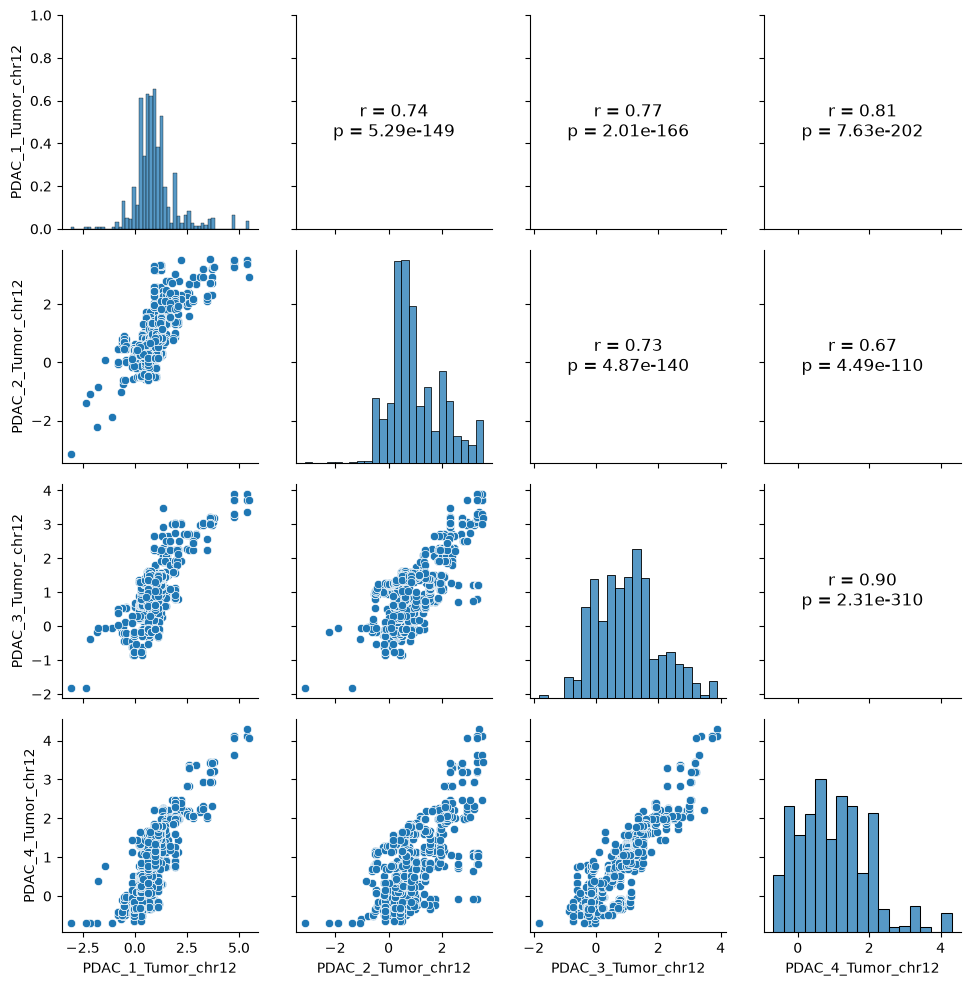

In [25]:
# ──────────────────────────────────────────────
# 1. 상관계수 표시 함수 정의
# ──────────────────────────────────────────────
def corrfunc(x, y, **kws):
    r, p = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}\np = {p:.2e}", 
                xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=12)

# ──────────────────────────────────────────────
# 2. PairGrid + map_upper 사용하여 pairplot 확장
# ──────────────────────────────────────────────
def pairplot_with_corr(df):
    grid = sns.PairGrid(df)
    grid = grid.map_upper(corrfunc)           # 상단 패널에 상관계수
    grid = grid.map_lower(sns.scatterplot)    # 하단 패널은 scatter
    grid = grid.map_diag(sns.histplot)        # diagonal은 hist
    return grid

# 예시 실행
g = pairplot_with_corr(dfs[cols])
plt.show()


In [ ]:
import anndata
import scanpy as sc

In [ ]:
# dfs['start'] = dfs['start'].astype(str)

dft = dfs[cols].transpose()
ad = anndata.AnnData(X = dft, var = dfs[['chr', 'start']])
ad.obs['grp'] = ['PDAC']*len(cols)
ad

In [ ]:
vg_pos = []
vg_labels = []

cnt = 0
for chr_name, grp in dfs.groupby('chr'):
    n = len(grp)
    end = max(cnt, cnt + n - 10)
    vg_pos.append((cnt, end))
    vg_labels.append(chr_name)
    cnt += n

vlim = np.quantile(dft, 0.97)

ax_dict = sc.pl.heatmap(ad, var_names = ad.var.index.values, groupby = 'grp', show = False,
                       figsize = (16, 2), swap_axes = False, show_gene_labels = True, # dendrogram = True,
                       var_group_positions = vg_pos, var_group_labels = vg_labels, var_group_rotation = 0,
                       vmax = vlim, vmin = -vlim)

N = 7
ax_dict['heatmap_ax'].set_xticks(range(len(ad.var_names))[::N])
ax_dict['heatmap_ax'].set_xticklabels(ad.var_names[::N], fontsize = 7)  

plt.show()